# Proyecto 7 - Explorando factores de comportamiento en NovaRetail+


NovaRetail+ es una plataforma de comercio electrónico en Latinoamérica con millones de usuarios.

Para el cierre de 2024, el equipo de **Crecimiento y retención** tiene como objetivo responder:

**¿Qué factores del comportamiento del cliente están más fuertemente asociados con el ingreso anual generado?**

> Este proyecto es un análisis **correlacional** (exploratorio).  
> **Correlación ≠ causalidad.**

## Sección 1 - Cargar y explorar el dataset

En esta sección validamos:
- que el dataset cargue correctamente
- tipos de datos
- valores faltantes / rangos generales

Antes de correlacionar, primero entendemos el “terreno”.

In [50]:
# Importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


### Cargar Dataset

In [51]:
# Cargar el dataset y explorar datos
df = pd.read_csv('/datasets/novaretail_comportamiento_clientes_2024.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  float64
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(5), int64(4), object(3)
memory usage: 1.4+ MB


#### Descripción del conjunto de datos

El dataset contiene las siguientes columnas:

- `id_cliente` — Identificador único del cliente.
- `edad` — Edad del cliente.
- `nivel_ingreso` — Ingreso anual estimado del cliente.
- `visitas_mes` — Número de visitas a la aplicación o sitio web durante el mes.
- `compras_mes` — Número de compras realizadas en el mes.
- `gasto_publicidad_dirigida` — Gasto en anuncios asignado al usuario.
- `satisfaccion` — Calificación de satisfacción del cliente en una escala del 1 al 5.
- `miembro_premium` — Indica si el cliente tiene suscripción premium (1) o no (0).
- `abandono` — Indica si el cliente abandonó la plataforma (1) o no (0).
- `tipo_dispositivo` — Tipo de dispositivo utilizado por el cliente (móvil, escritorio o tablet).
- `region` — Región geográfica del cliente (norte, sur, oeste o este).
- `ingreso_anual` — Ingreso anual generado por el cliente para la empresa.

La métrica principal de análisis es `ingreso_anual`, utilizada para evaluar el impacto económico de los clientes.


In [52]:
# mostrar las primeras 5 filas
df.head(5)

,id_cliente,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,tipo_dispositivo,region,ingreso_anual
0,CL-100000,44.0,28565.77,9,1,31.36,3.9,0,0,móvil,norte,23.22
1,CL-100001,36.0,29673.44,11,3,24.66,3.7,0,0,tablet,sur,93.47
2,CL-100002,46.0,30642.95,9,0,0.00,2.9,0,0,móvil,este,0.00
3,CL-100003,56.0,39468.61,8,0,6.81,3.1,0,0,móvil,este,0.00
4,CL-100004,35.0,22527.83,9,2,26.49,2.3,0,0,móvil,sur,33.76


## Sección 2 - Preparar datos y documentar supuestos

### Exploración y Limpieza

#### Exploración inicial de los datos
El conjunto de datos contiene **15,000 registros** y **12 columnas**, sin valores nulos.

**Variables numéricas**  
Se identifican las siguientes columnas numéricas:
- `edad`
- `nivel_ingreso`
- `visitas_mes`
- `compras_mes`
- `gasto_publicidad_dirigida`
- `satisfaccion`
- `ingreso_anual`

La mayoría de estas variables presentan tipos de datos adecuados.  
La columna `edad` tiene el tipo de variable decimal  y al tratarse de una edad se transformara a entero.


**Variables binarias**  
Las siguientes columnas representan variables binarias:
- `miembro_premium`
- `abandono`

Ambas están codificadas como 0 y 1, **no requieren transformación adicional**.

**Variables categóricas**  
Se identifican las siguientes columnas categóricas:
- `id_cliente`
- `tipo_dispositivo`
- `region`

Estas variables están correctamente definidas y no requieren transformación adicional.

In [53]:
# Corregir el tipo de dato
df['edad']=df['edad'].astype(int)

In [54]:
# verificar cambios
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  int64  
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(4), int64(5), object(3)
memory usage: 1.4+ MB


#### Explorar variables numéricas

In [55]:
# Estadísticas descriptivas de variables numéricas
columnas_numericas=['edad','nivel_ingreso','visitas_mes','compras_mes','gasto_publicidad_dirigida','satisfaccion','ingreso_anual']
print(df[columnas_numericas].describe())

               edad  nivel_ingreso   visitas_mes   compras_mes  \
count  15000.000000   15000.000000  15000.000000  15000.000000   
mean      38.262400   30019.704782     10.029000      1.206467   
std       11.492378    9833.166305      3.158189      1.105284   
min       18.000000    8000.000000      1.000000      0.000000   
25%       30.000000   23127.097500      8.000000      0.000000   
50%       38.000000   30023.745000     10.000000      1.000000   
75%       46.000000   36768.440000     12.000000      2.000000   
max       75.000000   74790.840000     25.000000      8.000000   

       gasto_publicidad_dirigida  satisfaccion  ingreso_anual  
count               15000.000000  15000.000000   15000.000000  
mean                   20.149301      3.603693      36.594180  
std                    10.880724      0.685300      34.484888  
min                     0.000000      1.000000       0.000000  
25%                    12.310000      3.100000       0.000000  
50%                  

Diagnóstico inicial de variables numéricas

- `edad` El promedio representa la edad tipica de los cliente.
- `nivel_ingreso`El promedio representa el ingreso anual estimado tipico para los clientes.
- `visitas_mes` el promedio representa el numero de visitas tipicas al mes de los clientes
- `compras_mes` el promedio representa el numero de compras tipicas de cada cliente.
- `gasto_publicidad_dirigida` el promedio represent el gasto en publicidad tipico asociado a los clientes.
- `satisfaccion` el promedio representa la calificacion tipica con la que los usuarios perciben la calidad del servicio.
- `ingreso_anual` el promedio puede estar influencia por valores atipicos.

#### Explorar variables binarias

In [56]:
# Verificar que cada columna tenga únicamente dos valores posibles
columnas_binarias=['miembro_premium','abandono']
print('numero de valores posibles por columna:')
print(df[columnas_binarias].nunique())
print('')
for col in columnas_binarias:
    print(f'conteo de la columna {col}')
    print(df[col].value_counts())
    print(f'distribucion de la columna {col}')
    print(df[col].value_counts(normalize=True))    
    print('')

numero de valores posibles por columna:
miembro_premium    2
abandono           2
dtype: int64

conteo de la columna miembro_premium
0    12911
1     2089
Name: miembro_premium, dtype: int64
distribucion de la columna miembro_premium
0    0.860733
1    0.139267
Name: miembro_premium, dtype: float64

conteo de la columna abandono
0    12739
1     2261
Name: abandono, dtype: int64
distribucion de la columna abandono
0    0.849267
1    0.150733
Name: abandono, dtype: float64




Diagnóstico inicial de variables binarias

- `miembro_premium` solo tiene 2 valores posibles en los cuales se evidencia que la mayoria de clientes no es cliente premium con un 86% de clientes que no son premium.
- `abandono` — solo tiene 2 valores posibles en las cuales se evidencia que la mayoria de clientes no ha abandona el servicio con un 85% de clientes que no han abandonado.

#### Explorar variables categóricas

In [57]:
# Verificar el número de valores únicos por variable categórica
columnas_categoricas=['tipo_dispositivo','region']
print(df[columnas_categoricas].nunique())

tipo_dispositivo    3
region              4
dtype: int64


In [58]:
# Explorar variables categóricas y cómo se distribuyen
for col in columnas_categoricas:
    print(f"Conteo de cada categoria para la columna {col}")
    print(df[col].value_counts())
    print(f"distribucion de cada categoria para la columna {col}")
    print(df[col].value_counts(normalize=True))
    print('')

Conteo de cada categoria para la columna tipo_dispositivo
móvil         9818
escritorio    3720
tablet        1462
Name: tipo_dispositivo, dtype: int64
distribucion de cada categoria para la columna tipo_dispositivo
móvil         0.654533
escritorio    0.248000
tablet        0.097467
Name: tipo_dispositivo, dtype: float64

Conteo de cada categoria para la columna region
norte    4395
oeste    3810
sur      3726
este     3069
Name: region, dtype: int64
distribucion de cada categoria para la columna region
norte    0.2930
oeste    0.2540
sur      0.2484
este     0.2046
Name: region, dtype: float64




Diagnóstico inicial de variables categóricas

- `tipo_dispositivo` tiene 3 categorias "móvil","escritorio","tablet" en los cuales la mayoria de clientes utilizan el movil con un 65% frente al total de registros.
- `region` representa los puntos cardinales donde la mayor concentracion se encuentra en el norte.

### Supuestos

- El análisis se realiza utilizando **todo el conjunto de datos disponible**.
- Los datos no presentan errores y están correctamente tipificados.
- Se utilizan distintos coeficientes según el tipo de variable:
  - **Pearson** asume relaciones lineales entre variables numéricas.
  - **Spearman** evalúa relaciones monótonas y no requiere normalidad.
  - **Punto biserial** se usa para relaciones numérica–binaria.
  - **Cramér (V)** se usa para asociaciones entre variables categóricas.

**Supuesto central:**  
Este análisis identifica relaciones entre variables o segmentos, pero no prueba causalidad.

## Sección 3 - Visualización de relaciones

Observamos cómo se relacionan las variables numéricas.

### Heatmap

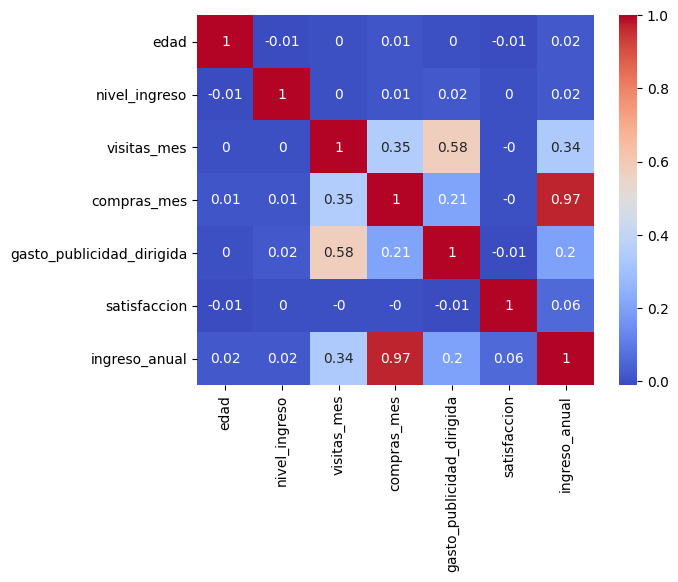

<Figure size 1500x600 with 0 Axes>

In [59]:
# Visualizar la matriz de correlación para identificar relaciones
corrdf=df[columnas_numericas].corr().round(2)
sns.heatmap(corrdf,annot=True,cmap='coolwarm')
plt.figure(figsize=(15,6))
plt.show()


Observaciones generales (Heatmap)  
- Se observa una relacion directa considerable entre el gasto de publicidad dirigida y la cantidad de visitas al mes, al igual que una relacion directa entre las compras y visitas al mes y finalmente relacion baja entre gasto de publicidad dirigida y compras al mes.


Observaciones respecto a `ingreso_anual`  
- Presenta relacion fuerte entre las compras por mes y el ingreso anual, seguido de una relacion menos fuerte con las variables de visitas mensuales que puede estar asociada al gasto publicitario dirigido.


### Scatterplot general

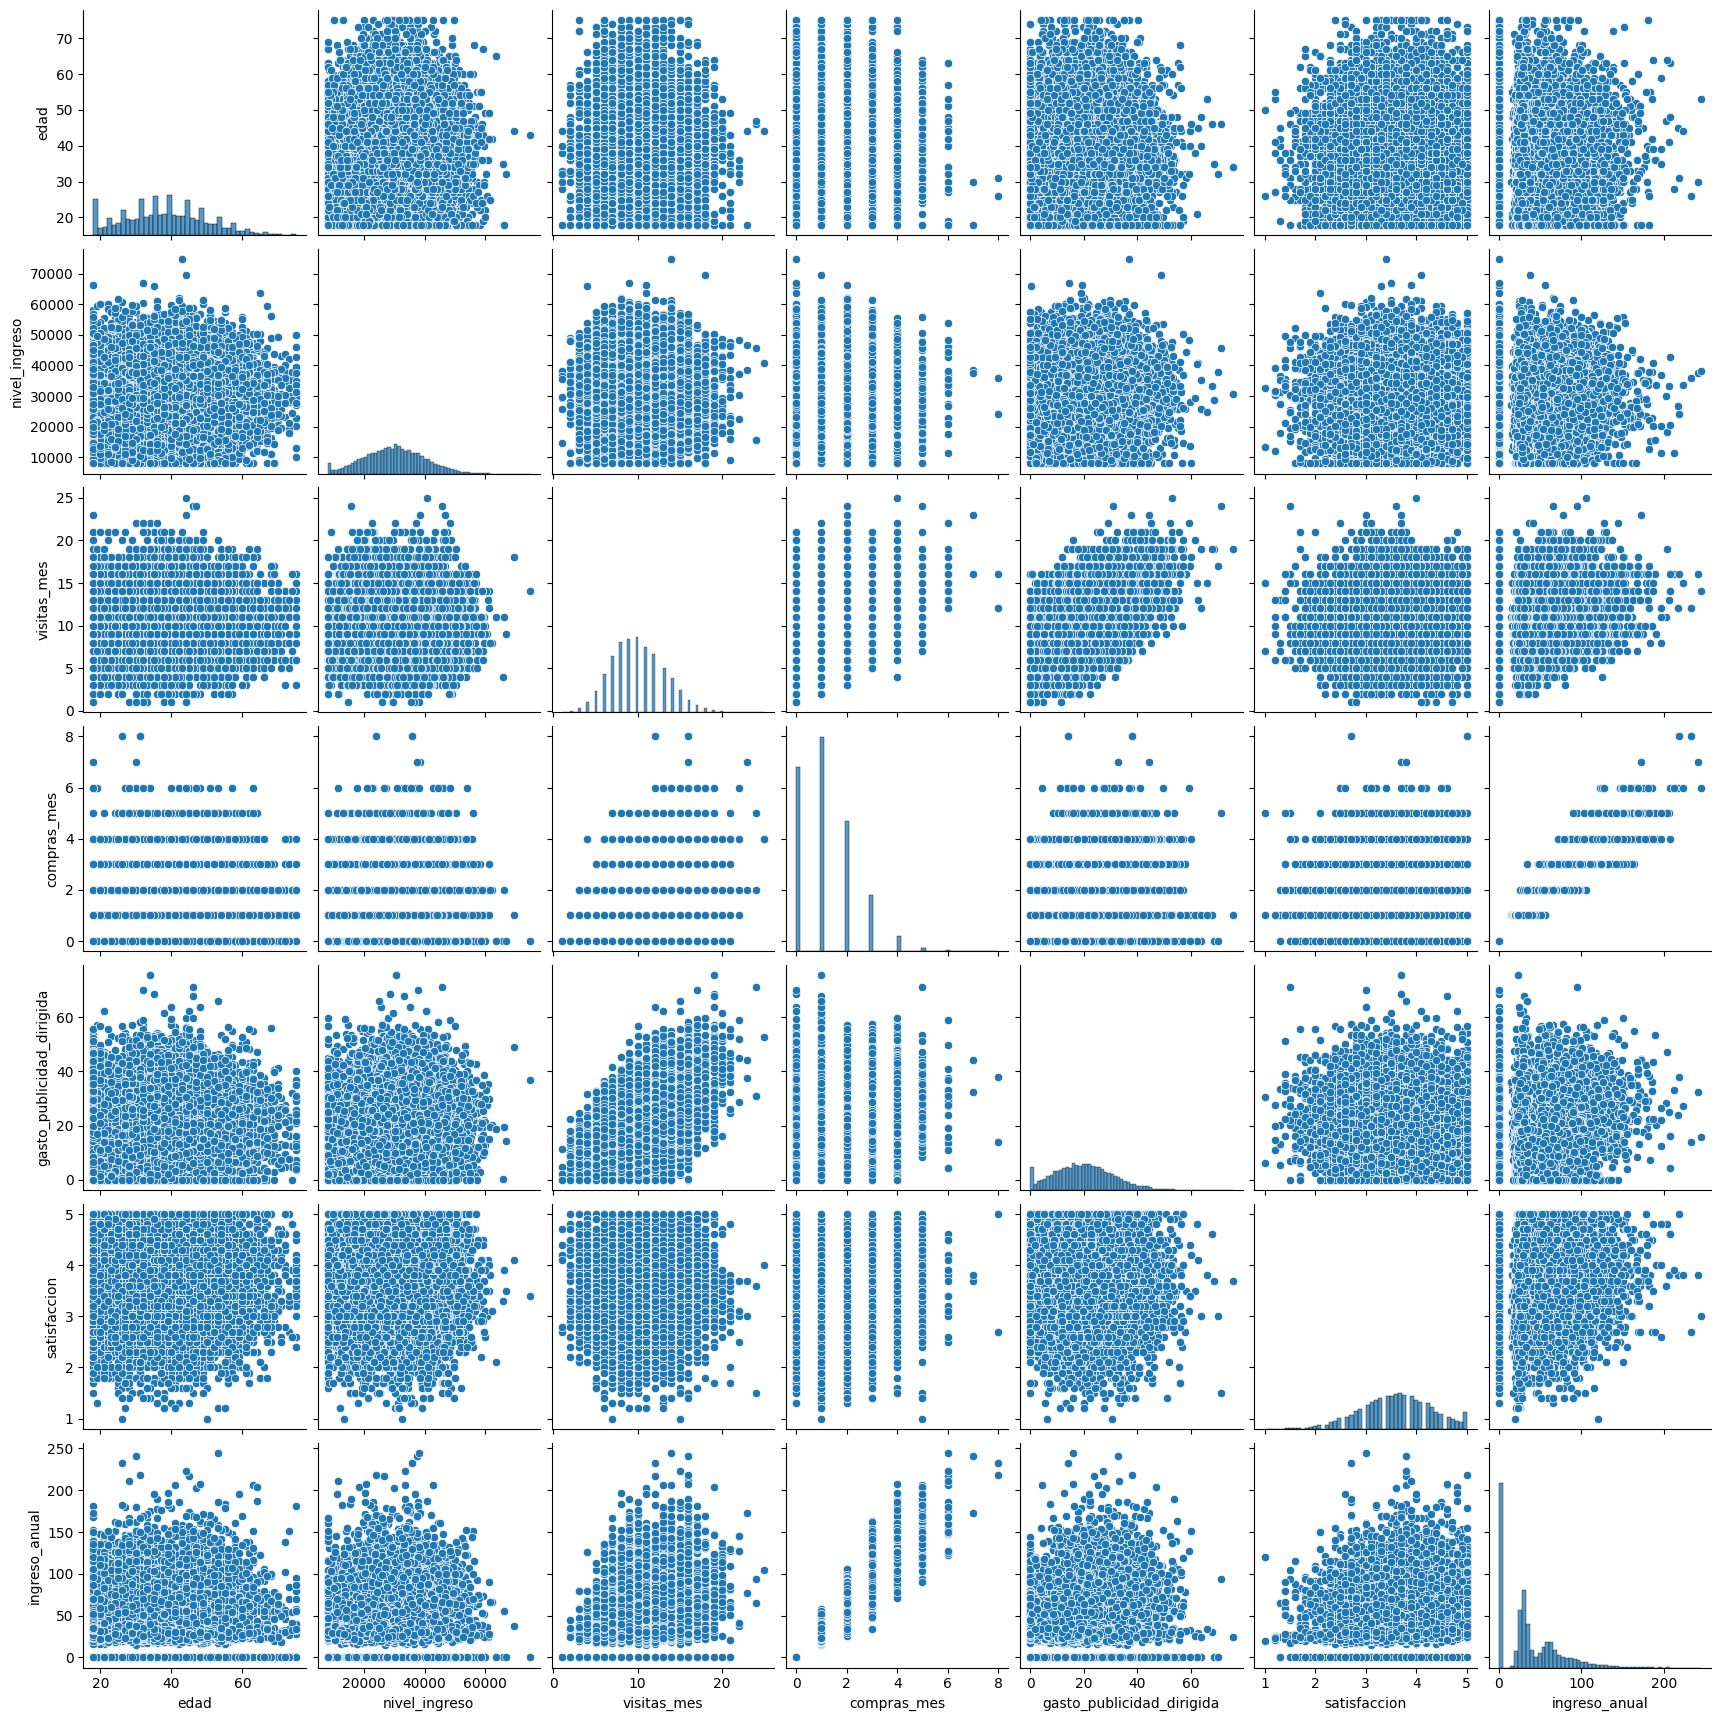

In [60]:
sns.pairplot(df[columnas_numericas])
plt.show()

Al realizar un analisis visual de las relaciones entre cada variable se puede visualizar que las que se ven mayormente relacionadas son las siguientes parejas:


- compras_mes y ingreso_anual
- visitas_mes y ingreso_anual
- visitas_mes y gasto_publicidad_dirigida
- visitas_mes y compras_mes
- ingreso_anual y gasto_publicidad_dirigida
- compras_mes y gasto_publicidad_dirigida

  
lo anterior permite entender de manera visual la relacion que se obtuvo mediante el Heatmap.

### Scatterplot para pares clave

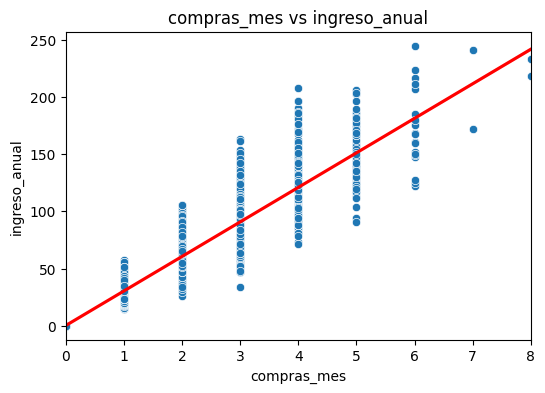

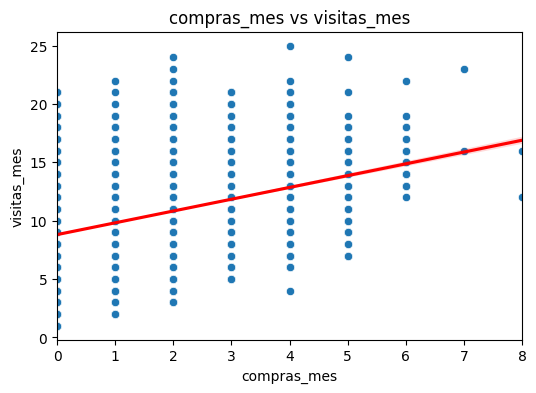

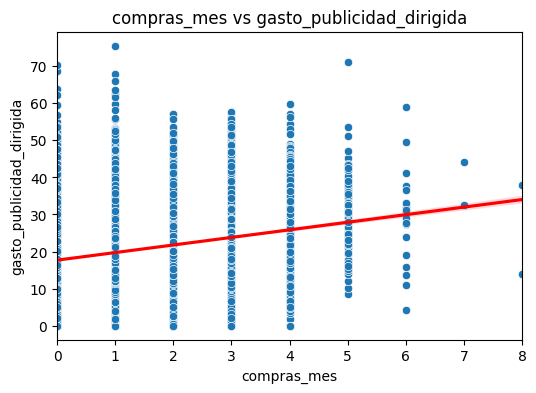

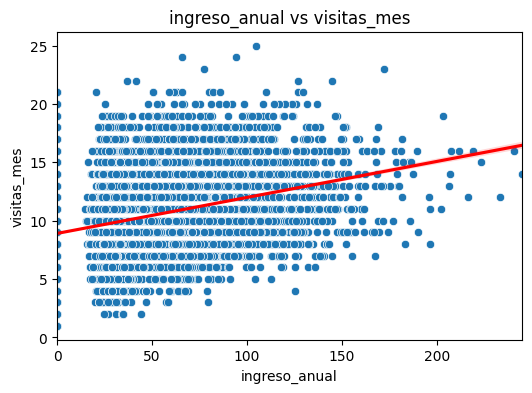

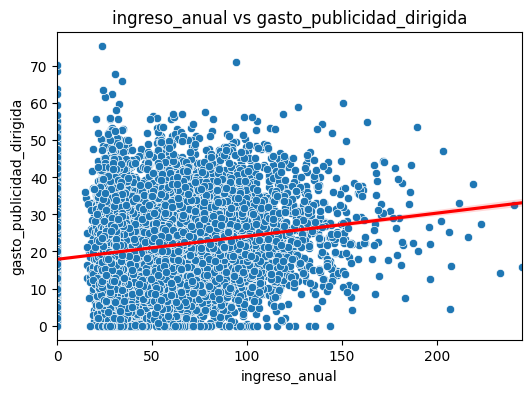

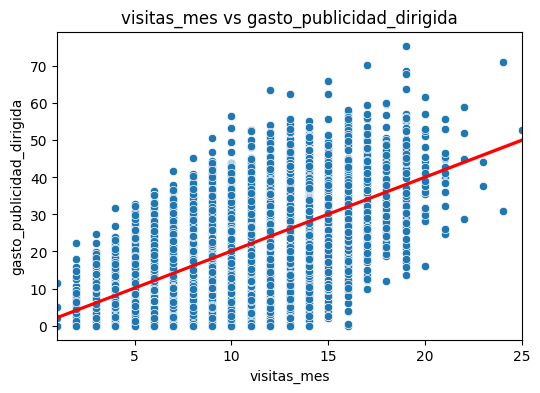

In [61]:
# Visualizar pares de variables con relaciones moderadas o fuertes
columnas_relacionadas=['compras_mes','ingreso_anual','visitas_mes','gasto_publicidad_dirigida']
for i in range(len(columnas_relacionadas)):
    for j in range(i+1, len(columnas_relacionadas)):

        col1 = columnas_relacionadas[i]
        col2 = columnas_relacionadas[j]

        plt.figure(figsize=(6,4))

        sns.scatterplot(data=df, x=col1, y=col2)
        sns.regplot(data=df, x=col1, y=col2, scatter=False, color='red')

        plt.title(f'{col1} vs {col2}')
        plt.show()



Observaciones iniciales (Scatterplot)

**compras_mes y ingreso_anual**
- direccion: positiva
- dispersion:baja
- posible presencia de outliers:no
- posible colinealidad:si
  
**visitas_mes y ingreso_anual**
- direccion:positiva
- dispersion: media
- posible presencia de outliers:no
- posible colinealidad: no
  
**visitas_mes y gasto_publicidad_dirigida**
- direccion:positiva
- dispersion:media
- posible presencia de outliers:no
- posible colinealidad:no
  
**visitas_mes y compras_mes**
- direccion:positiva
- dispersion: alta
- posible presencia de outliers: no
- posible colinealidad: no

**compras_mes y gasto_publicidad_dirigida**
- direccion:positiva
- dispersion:alta
- posible presencia de outliers:no
- posible colinealidad:no

**ingreso_anual y gasto_publicidad_dirigida**
- direccion:positiva
- dispersion:alta
- posible presencia de outliers:no
- posible colinealidad:no


## Sección 4 - Coeficientes de correlación y evidencia numérica

En esta sección, se reportan coeficientes que respaldan los patrones
observados visualmente, utilizando el método adecuado según el tipo
de variables.

### Pearson / Spearman

In [62]:
# Calcular correlación entre variables relevantes

for i in range(len(columnas_relacionadas)):
    for j in range(i+1, len(columnas_relacionadas)):
        col1 = columnas_relacionadas[i]
        col2 = columnas_relacionadas[j]

        corr = df[col1].corr(df[col2], method='pearson')

        tipo = "positiva" if corr > 0 else "negativa"

        print(f'Coeficiente de correlación entre {col1} y {col2}: {corr:.2f}')

        if abs(corr) > 0.85:
            print(f'Existe posible colinealidad {tipo} con valor {corr:.2f}')
        elif 0.75 < abs(corr) <= 0.85:
            print(f'Relación lineal {tipo} fuerte: {corr:.2f}')
        elif 0.5 < abs(corr) <= 0.75:
            print(f'Relación lineal {tipo} moderada: {corr:.2f}')
        elif 0.15 < abs(corr) <= 0.5:
            print(f'Relación lineal {tipo} baja: {corr:.2f}')
        else:
            print(f'No hay relación lineal significativa: {corr:.2f}')
        print('')

        

Coeficiente de correlación entre compras_mes y ingreso_anual: 0.97
Existe posible colinealidad positiva con valor 0.97

Coeficiente de correlación entre compras_mes y visitas_mes: 0.35
Relación lineal positiva baja: 0.35

Coeficiente de correlación entre compras_mes y gasto_publicidad_dirigida: 0.21
Relación lineal positiva baja: 0.21

Coeficiente de correlación entre ingreso_anual y visitas_mes: 0.34
Relación lineal positiva baja: 0.34

Coeficiente de correlación entre ingreso_anual y gasto_publicidad_dirigida: 0.20
Relación lineal positiva baja: 0.20

Coeficiente de correlación entre visitas_mes y gasto_publicidad_dirigida: 0.58
Relación lineal positiva moderada: 0.58



In [63]:
# Calcular correlación entre variables relevantes

for i in range(len(columnas_relacionadas)):
    for j in range(i+1, len(columnas_relacionadas)):
        col1 = columnas_relacionadas[i]
        col2 = columnas_relacionadas[j]

        corr = df[col1].corr(df[col2], method='spearman')

        tipo = "positiva" if corr > 0 else "negativa"

        print(f'Coeficiente de correlación entre {col1} y {col2}: {corr:.2f}')

        if abs(corr) > 0.85:
            print(f'Existe posible colinealidad {tipo} con valor {corr:.2f}')
        elif 0.75 < abs(corr) <= 0.85:
            print(f'Relación monotona {tipo} fuerte: {corr:.2f}')
        elif 0.5 < abs(corr) <= 0.75:
            print(f'Relación monotona {tipo} moderada: {corr:.2f}')
        elif 0.15 < abs(corr) <= 0.5:
            print(f'Relación monotona {tipo} baja: {corr:.2f}')
        else:
            print(f'No hay relación monotona significativa: {corr:.2f}')
        print('')

Coeficiente de correlación entre compras_mes y ingreso_anual: 0.97
Existe posible colinealidad positiva con valor 0.97

Coeficiente de correlación entre compras_mes y visitas_mes: 0.33
Relación monotona positiva baja: 0.33

Coeficiente de correlación entre compras_mes y gasto_publicidad_dirigida: 0.19
Relación monotona positiva baja: 0.19

Coeficiente de correlación entre ingreso_anual y visitas_mes: 0.32
Relación monotona positiva baja: 0.32

Coeficiente de correlación entre ingreso_anual y gasto_publicidad_dirigida: 0.18
Relación monotona positiva baja: 0.18

Coeficiente de correlación entre visitas_mes y gasto_publicidad_dirigida: 0.56
Relación monotona positiva moderada: 0.56



**Nota:** Los coeficientes de correlacion de pearson y spearman son similares por lo que podriamos decir que no se tiene una relacion monotonica sino practicamente lineal.

### Punto-biserial

In [64]:
# Calcular correlación entre variables relevantes
from scipy.stats import pointbiserialr
for col1 in columnas_binarias:
    for col2 in columnas_numericas:
        biserial,p=pointbiserialr(df[col1],df[col2])
        tipo= 'positiva' if biserial>0 else 'negativa'
        print(f'Coeficiente punto biserial entre {col1} y {col2}: {biserial:.2f}')
        if biserial>0.5:
            print(f'Existe relacion {tipo} fuerte con valor {biserial:.2f}')
        elif 0.5>=biserial>0.3:
            print(f'Existe relacion {tipo} moderada con valor {biserial:.2f}')
        elif 0.3>=biserial>0.1:
            print(f'Existe relacion {tipo} debil con valor {biserial:.2f}')
        else:
            print(f'No existe relacion significativa con direccion {tipo} de {biserial:.2f}')
        print('')


Coeficiente punto biserial entre miembro_premium y edad: 0.00
No existe relacion significativa con direccion positiva de 0.00

Coeficiente punto biserial entre miembro_premium y nivel_ingreso: -0.01
No existe relacion significativa con direccion negativa de -0.01

Coeficiente punto biserial entre miembro_premium y visitas_mes: -0.01
No existe relacion significativa con direccion negativa de -0.01

Coeficiente punto biserial entre miembro_premium y compras_mes: 0.00
No existe relacion significativa con direccion positiva de 0.00

Coeficiente punto biserial entre miembro_premium y gasto_publicidad_dirigida: 0.00
No existe relacion significativa con direccion positiva de 0.00

Coeficiente punto biserial entre miembro_premium y satisfaccion: 0.03
No existe relacion significativa con direccion positiva de 0.03

Coeficiente punto biserial entre miembro_premium y ingreso_anual: 0.09
No existe relacion significativa con direccion positiva de 0.09

Coeficiente punto biserial entre abandono y ed

### V de Cramér

In [65]:
# Función para calcular V de Cramér
from scipy.stats import chi2_contingency
def cramer_v(df,col1,col2):
    tabla=pd.crosstab(df[col1],df[col2])
    chi2,p,dof,expected=chi2_contingency(tabla)
    n=tabla.sum().sum()
    cramer_v=np.sqrt(chi2/(n*(min(tabla.shape[0], tabla.shape[1])-1)))
    return print(f' v de cramer: {cramer_v}')
    

In [66]:
# Aplicar V de Cramér en variables relevantes
cramer_v(df,'tipo_dispositivo','region')


 v de cramer: 0.012378338407739397


La relacion entre Region y tipo de dispositivo es muy debil, lo que quiere decir que el dispositivo que usan los usuarios no varia signficativamente entre las diferentes regiones.


## Sección 5 - Interpretación de resultados para el negocio

Cada hallazgo  debe incluir:
1) Evidencia visual (si aplica)
2) Evidencia numérica  
3) Interpretación (no causal)  
4) No podemos afirmar
5) Implicación de negocio

---

### Hallazgo 1 — ingreso_anual y visitas_mes

**Evidencia visual:** scatterplot y heatmap

**Evidencia numérica:** pearson: 0.34

**Interpretación**  
Se observa una relación positiva moderada entre el número de visitas y los ingresos anuales. En general, los usuarios con más visitas tienden a estar asociados con mayores niveles de ingresos, aunque la relación no es fuerte y presenta variabilidad.

**No podemos afirmar**  
No es posible concluir que un aumento en el número de visitas cause un incremento directo en los ingresos, ya que la relación observada es correlacional y de intensidad moderada

**Implicación de negocio**
El aumento en el número de visitas puede contribuir al crecimiento de los ingresos, pero no es un factor determinante por sí solo. 
Esto implica que las estrategias de adquisición de tráfico deben complementarse con iniciativas orientadas a mejorar la conversión y la calidad del tráfico, maximizando el valor generado por cada visita


### Hallazgo 2 — ingreso_anual y gasto_publicidd_dirigida

**Evidencia visual:**   heatmap y scatterplot

**Evidencia numérica:** pearson : 0.2

**Interpretación**  
Se observa una relación positiva débil entre el gasto en publicidad dirigida y los ingresos anuales. Aunque existe una tendencia creciente, la alta dispersión de los datos indica que el gasto publicitario por sí solo no explica de manera significativa el comportamiento de los ingresos.

**No podemos afirmar**  
entre mas gasto publicitario mayor seran los ingresos

**Implicación de negocio**  

El gasto en publicidad dirigida tiene un impacto limitado en la generación de ingresos, lo que sugiere que incrementar la inversión publicitaria no garantiza un aumento proporcional en los resultados.
Esto implica que la efectividad de la publicidad depende de otros factores como la segmentación, la calidad del mensaje, el canal utilizado y la experiencia del cliente.
Se recomienda optimizar las campañas publicitarias en lugar de simplemente aumentar el presupuesto, enfocándose en mejorar el retorno sobre la inversión (ROI) y en identificar qué segmentos de clientes responden mejor a la publicidad.



## Sección 6 - Limitaciones y próximos pasos

### **Limitaciones**
- La correlación identificada no implica causalidad, por lo que no se puede concluir que una variable genere cambios directos sobre la otra.
- El análisis no incluye segmentaciones clave lo que puede ocultar relaciones más fuertes.
- No se han considerado variables adicionales que podrían estar influyendo en los resultados (variables omitidas).
- La presencia de outliers y la alta dispersión pueden estar afectando la magnitud de las correlaciones.
- Algunas variables presentan distribuciones sesgadas (colas largas), lo que puede distorsionar métricas como Pearson

### **Próximos pasos** 


- Realizar segmentación de clientes para identificar patrones más específicos:
    - tipo de dispositivo
    - región

- Aplicar transformación de variables en variables con alta asimetría para mejorar el análisis de relaciones.

- Analizar y tratar outliers para comprender si representan errores, casos especiales o segmentos de alto valor.